In [ ]:
#A kernel lets an SVM solve nonlinear classification problems without explicitly transforming the data into a higher-dimensional space. This is known as the kernel trick

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from matplotlib.colors import ListedColormap

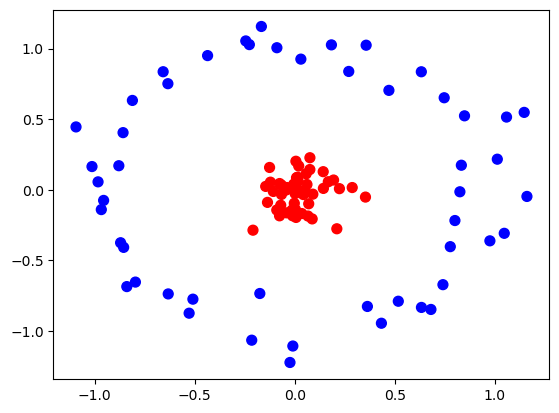

In [70]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr') 

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

## linear kernel

In [75]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.3

In [79]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\sampada\AppData\Local\Temp\ipykernel_15480\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


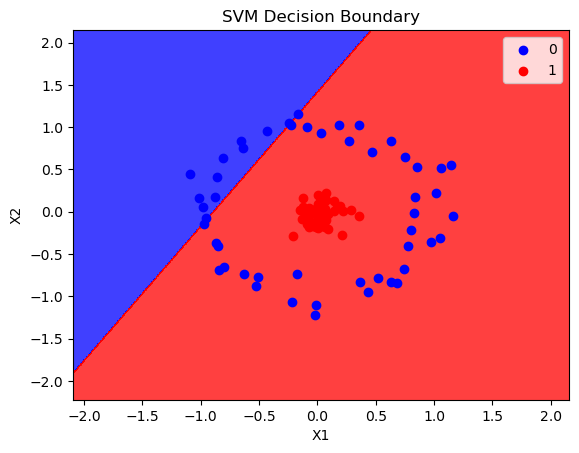

In [81]:

plot_decision_boundary(X, y, classifier)

In [25]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

## Radial Basis fxn (RBF) kernel

In [30]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

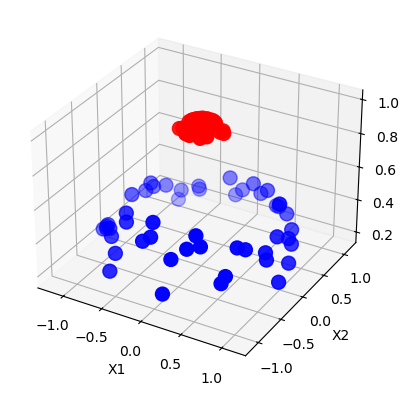

In [32]:
plot_3d_plot(X,y)

In [34]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\sampada\AppData\Local\Temp\ipykernel_15480\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


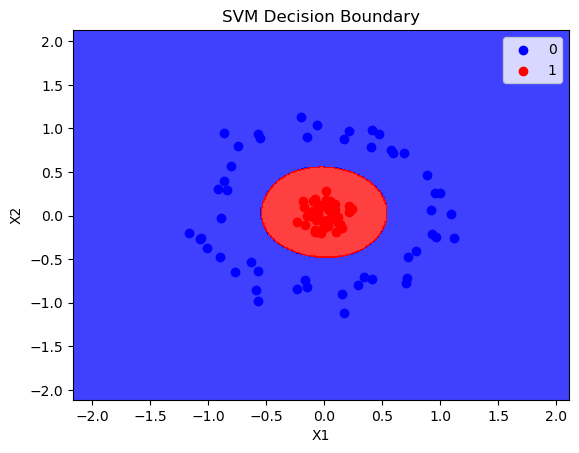

In [36]:
plot_decision_boundary(X, y, rbf_classifier)

## Polynomial kernel

In [38]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [40]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\sampada\AppData\Local\Temp\ipykernel_15480\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


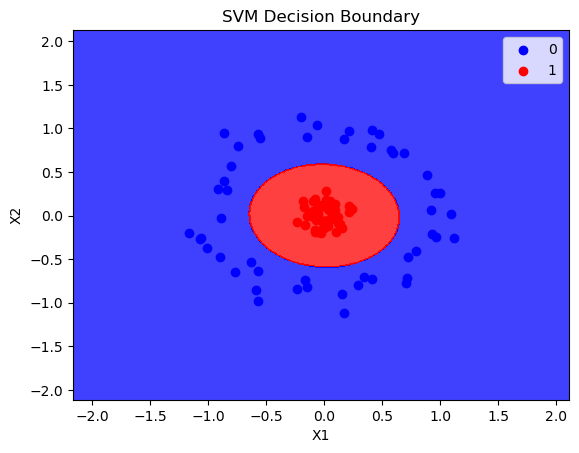

In [42]:
plot_decision_boundary(X, y, poly_classifier)

In [83]:
X

array([[ 1.41768981e-02,  8.94890593e-02],
       [-1.25779744e-01,  1.58593355e-01],
       [ 2.06886558e-03, -2.61684314e-02],
       [-6.34410787e-01,  7.51767475e-01],
       [ 2.10601997e-01, -2.75564728e-01],
       [ 7.56655403e-02,  1.43904137e-01],
       [ 3.57228407e-01,  1.02427834e+00],
       [ 2.23582378e-01,  8.49556065e-03],
       [-6.58125505e-01,  8.36421205e-01],
       [ 6.33804332e-01, -8.32517360e-01],
       [ 1.62609575e-02,  6.45206164e-02],
       [-2.18732245e-03, -9.50134278e-02],
       [ 5.86362864e-03,  2.02620109e-01],
       [ 7.78066211e-01, -4.02250780e-01],
       [ 1.94250492e-01,  6.95786553e-02],
       [ 3.06777243e-02,  9.25667939e-01],
       [ 6.99748337e-02, -9.84658524e-02],
       [-6.63451852e-02, -3.22442359e-02],
       [-9.83719536e-01,  5.67231894e-02],
       [-7.59542832e-02, -1.83885005e-01],
       [ 1.16138613e+00, -4.66510302e-02],
       [ 8.88988905e-03,  8.60246964e-02],
       [-8.79742295e-01,  1.70907934e-01],
       [ 1.

In [85]:
np.exp(-(X**2)).sum(1)

array([1.99182272, 1.95946576, 1.99931117, 1.23693412, 1.88349162,
       1.97379563, 1.23043139, 1.95116764, 1.14526048, 1.16920718,
       1.99558136, 1.99100829, 1.95974205, 1.39646959, 1.95814029,
       1.42355174, 1.98546682, 1.99456884, 1.37674202, 1.96099915,
       1.25737298, 1.99254804, 1.43240234, 1.31542544, 1.9722139 ,
       1.99090211, 1.31214462, 1.25104553, 1.96253873, 1.92038626,
       1.27074265, 1.24591738, 1.99704803, 1.87971038, 1.99446987,
       1.98847438, 1.98336232, 1.22387921, 1.9635012 , 1.98050701,
       1.95098196, 1.40981756, 1.99822006, 1.98397429, 1.32701365,
       1.39547103, 1.55350736, 1.18691826, 1.48011372, 1.97955654,
       1.29700566, 1.23844576, 1.24312035, 1.87901434, 1.00797854,
       1.99687056, 1.2634379 , 1.23481106, 1.99839377, 1.22293094,
       1.97105257, 1.27682726, 1.99752047, 1.32081583, 1.97955429,
       1.9717964 , 1.97147725, 1.12211292, 1.21436368, 1.11937041,
       1.0922632 , 1.16669551, 1.96177708, 1.42466588, 1.23201

In [87]:
X_new=np.exp(-(X**2))

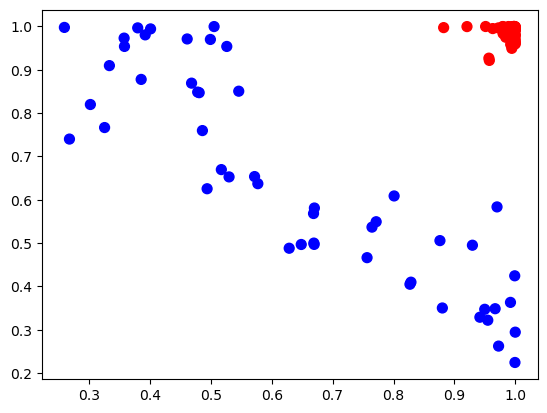

In [89]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')